In [1]:
import torch
import matplotlib.pyplot as plt

from src.diffeomorphisms.vector.star_gaussian import StarGaussianVectorDiffeomorphism
from src.distributions.star_gaussians.r2.cross import CrossStarGaussianDistribution

# seed
torch.manual_seed(31)

In [2]:
# construct star distribution
dist = CrossStarGaussianDistribution()

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


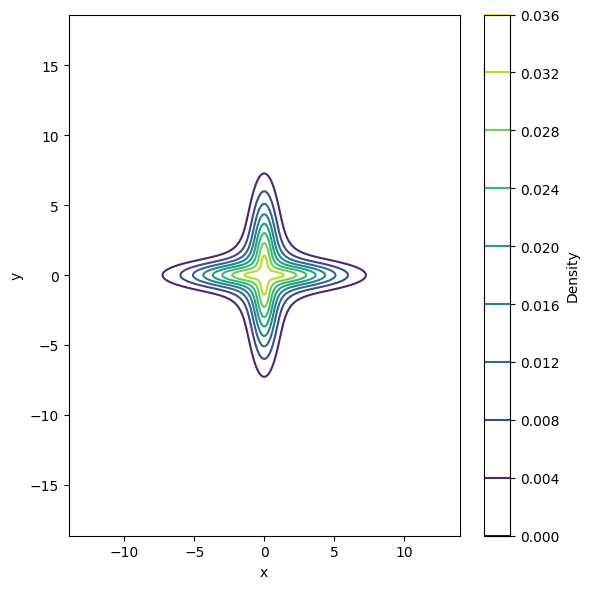

In [3]:
# plot density
n_points = 1001
x = torch.linspace(-14, 14, n_points)
y = torch.linspace(-14, 14, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs = torch.exp(dist.log_prob(XY).reshape(n_points, n_points).detach())

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs.numpy(), levels=10, cmap='viridis')
plt.colorbar(label='Density')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.show()

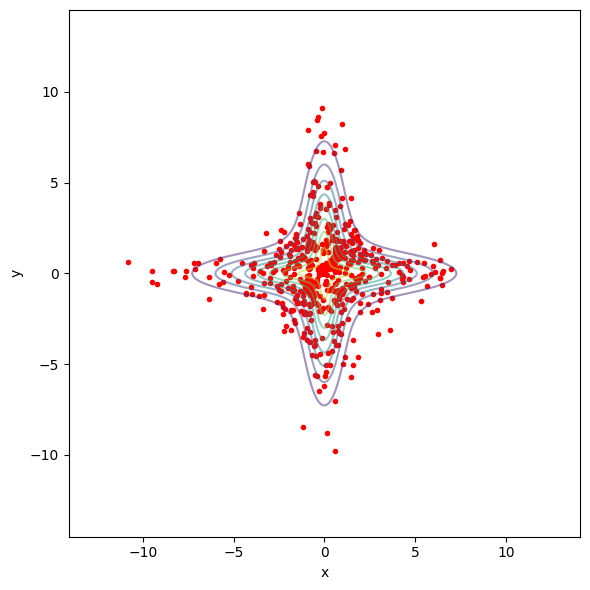

In [4]:
# generate samples
samples = dist.sample(500).detach().numpy()

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs.numpy(), levels=10, cmap='viridis', alpha=0.5)
plt.scatter(samples[:,0], samples[:,1], marker='.', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [5]:
# check normalization integrates to 1 by monte carlo from uniform samples
n_mc_samples = 1000000
mc_samples = (torch.rand(n_mc_samples, 2) - 0.5) * 28.0  # uniform in [-14, 14]^2
mc_log_probs = dist.log_prob(mc_samples)
mc_probs = torch.exp(mc_log_probs)
mc_integral = mc_probs.mean() * (28.0 ** 2)  # area of bounding box
print(f'Monte Carlo integral estimate: {mc_integral.item()}')


Monte Carlo integral estimate: 0.9747768640518188


In [6]:
# Construct radial vector diffeomorphism
radial_diffeo = StarGaussianVectorDiffeomorphism(dist)

In [7]:
# test forward and inverse
x = torch.tensor([[8.0, 0.0], [0.0, 8.0], [-5.0, 1.0], [-1.0, -5.0]])
y = radial_diffeo.forward(x)
x_recon = radial_diffeo.inverse(y)  
print("Original x:\n", x)
print("Transformed y:\n", y)
print("Reconstructed x:\n", x_recon)

Original x:
 tensor([[ 8.,  0.],
        [ 0.,  8.],
        [-5.,  1.],
        [-1., -5.]])
Transformed y:
 tensor([[ 2.2857,  0.0000],
        [ 0.0000,  2.2857],
        [-2.0258,  0.4052],
        [-0.4052, -2.0258]])
Reconstructed x:
 tensor([[ 8.,  0.],
        [ 0.,  8.],
        [-5.,  1.],
        [-1., -5.]])


In [8]:
# Construct pullback manifold from radial diffeomorphism
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean

manifold = StandardPullbackVectorEuclidean(radial_diffeo)

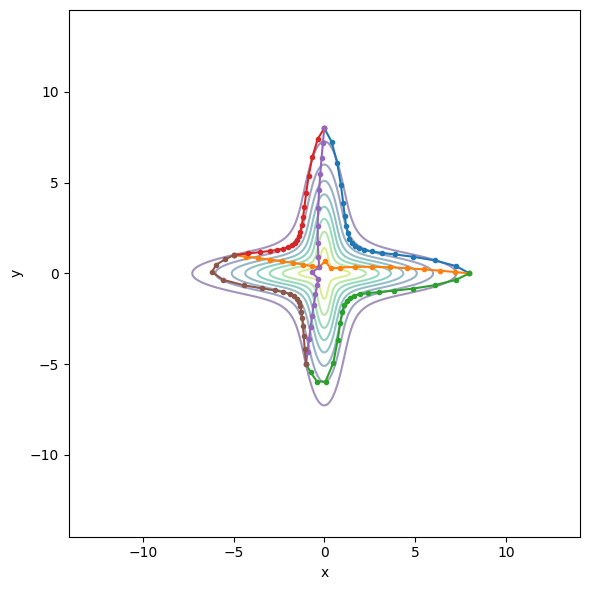

In [9]:
# compute geodesics between all of the x points
geodesics = manifold.geodesic(x[None],x[None],torch.linspace(0,1,20))

# plot geodesics
plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs.numpy(), levels=10, cmap='viridis', alpha=0.5)
for i in range(geodesics.shape[1]):
    for j in range(i+1, geodesics.shape[1]):
        plt.plot(geodesics[0, i, j, :, 0].numpy(), geodesics[0, i, j, :, 1].numpy(), marker='.')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.show()

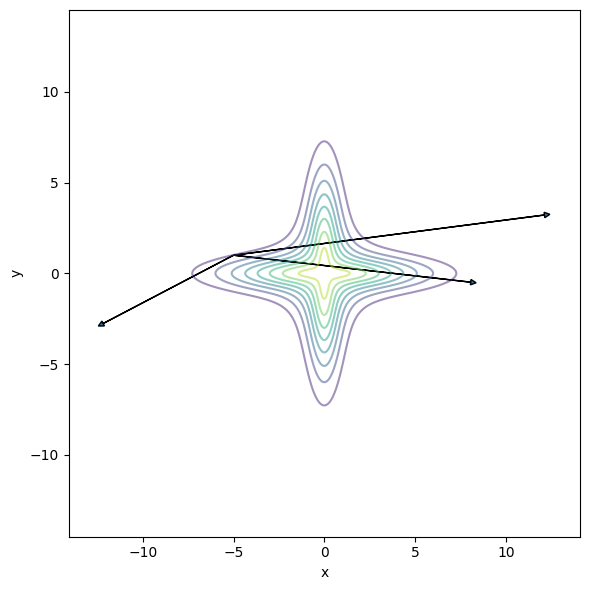

In [10]:
# compute logs between the western most point and the other points
logs = manifold.log(x[2][None,None], x[[0,1,3]][None])

# quiver plot of the log vectors
plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs.numpy(), levels=10, cmap='viridis', alpha=0.5)
for i in range(logs.shape[2]):
    plt.arrow(x[2,0].item(), x[2,1].item(), logs[0,0,i,0].item(), logs[0,0,i,1].item(), head_width=0.3, head_length=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [11]:
# compute exps of the log vectors to see whether we get the same points back
recon_points = manifold.exp(x[2][None], logs[0])

print("Original points:\n", x[[0,1,3]])
print("Reconstructed points from exp(log):\n", recon_points)

Original points:
 tensor([[ 8.,  0.],
        [ 0.,  8.],
        [-1., -5.]])
Reconstructed points from exp(log):
 tensor([[[ 8.0000e+00,  9.3877e-07],
         [-4.1723e-06,  8.0000e+00],
         [-1.0000e+00, -5.0000e+00]]])


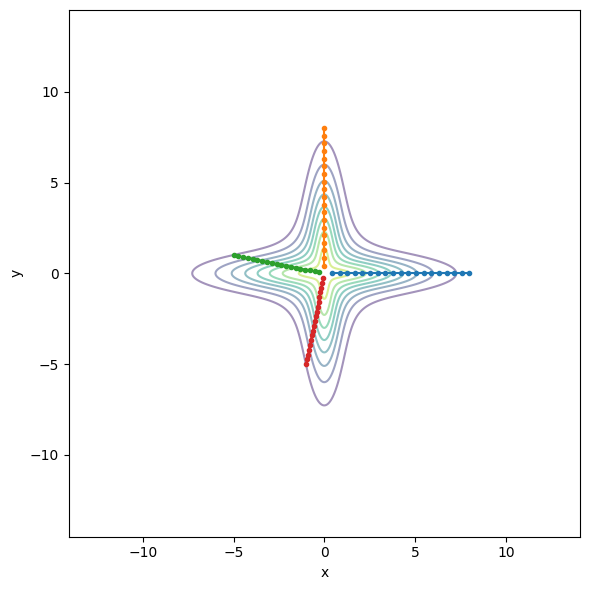

In [12]:
# geodesics from the origin now
origin = torch.tensor([[0.0, 0.0]])
geodesics_from_origin = manifold.geodesic(origin[None], x[None], torch.linspace(0,1,20))

# plot geodesics from origin
plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs.numpy(), levels=10, cmap='viridis', alpha=0.5)
for i in range(geodesics_from_origin.shape[2]):
    plt.plot(geodesics_from_origin[0, 0, i, :, 0].numpy(), geodesics_from_origin[0, 0, i, :, 1].numpy(), marker='.')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.show()  

Logs from origin to other points:
 tensor([[[[ 2.2857,  0.0000],
          [ 0.0000,  2.2857],
          [-2.0258,  0.4052],
          [-0.4052, -2.0258]]]])


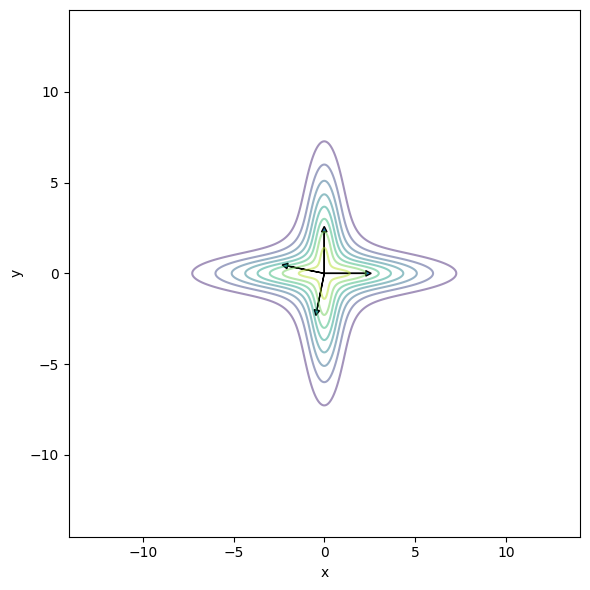

In [13]:
# logs from origin to the other points
logs_from_origin = manifold.log(origin[None], x[None])
print("Logs from origin to other points:\n", logs_from_origin)

# quiver plot of the log vectors from origin
plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs.numpy(), levels=10, cmap='viridis', alpha=0.5)
for i in range(logs_from_origin.shape[2]):
    plt.arrow(origin[0,0].item(), origin[0,1].item(), logs_from_origin[0,0,i,0].item(), logs_from_origin[0,0,i,1].item(), head_width=0.3, head_length=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [14]:
# compute the exps of the log vectors from origin to see whether we get the same points back
recon_points_from_origin = manifold.exp(origin, logs_from_origin[0])
print("Original points:\n", x)
print("Reconstructed points from exp(log) from origin:\n", recon_points_from_origin)    


Original points:
 tensor([[ 8.,  0.],
        [ 0.,  8.],
        [-5.,  1.],
        [-1., -5.]])
Reconstructed points from exp(log) from origin:
 tensor([[[ 8.,  0.],
         [ 0.,  8.],
         [-5.,  1.],
         [-1., -5.]]])
